In [77]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import astropy

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, savefig, close
import matplotlib.font_manager as fm
import itertools
from matplotlib import rcParams
import scienceplots
import pickle

from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

import os
import xarray as xr
from taurex.cache import OpacityCache, CIACache
OpacityCache().set_opacity_path('./xsec/')
CIACache().set_cia_path('./cia/')

from taurex.temperature import TemperatureFile
from taurex.chemistry import TaurexChemistry
from taurex.chemistry import ConstantGas

from taurex.planet import Planet
from taurex.stellar import BlackbodyStar, PhoenixStar

from taurex.model import EmissionModel, TransmissionModel
from taurex.pressure import SimplePressureProfile

from taurex.contributions import AbsorptionContribution
from taurex.contributions import CIAContribution
from taurex.contributions import RayleighContribution

from taurex.binning import FluxBinner

In [2]:
planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
planet_fullnames = ["HD3167b","K2-141b","LHS1478b","TOI-431b","TOI-500b","TOI-561b","TOI-1416b","TOI-1807b"]
planet_masses = [4.73, 4.97, 2.33, 3.07, 1.42, 2.02, 3.48, 2.44] #Earth masses
planet_distances = [0.018, 0.007, 0.018, 0.011, 0.012, 0.011, 0.019, 0.012] #AU
planet_period = [0.96, 0.28, 1.95, 0.49, 0.55, 0.45, 1.0, 0.55] #days
planet_radius = [1.627, 1.510, 1.242, 1.277, 1.166, 1.397, 1.620, 1.496] #Earth radii
planet_transit = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours
planet_transit = [n * 3600 for n in planet_transit] #hours to seconds
T_transit_hours = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours
planet_impact = [0.181, -0.01, 0.717, 0.34, 0.53, 0.14, 0.39, 0.489] #to be fixed according to archive data
planet_eccentricity = [0.05, 0.0, 0.0, 0.0, 0.06, 0.0, 0.0, 0.0] #to be fixed according to archive data
planet_pericentre_long = [0.0, 90.0, 0.0, 0.0, 228.5, 0.0, 0.0, 90.0] #w, to be fixed according to archive data

star_temperature = [5261.0,4570.0,3381.0,4850.0,4440.0,5342.0,4884.0,4914.0] #Kelvin
star_radius = [0.872,0.681,0.246,0.731,0.678,0.856,0.793,0.746] #Solar radii
star_metallicity = [0.03, 0.0, -0.13, 0.2, 0.12, -0.4, 0.08, -0.04] #[Fe/H]
star_logg = [4.5, 4.6, 4.9, 4.6, 4.6, 4.5, 4.5, 4.6]
star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3] #Gyr
star_distance = [47.28, 61.87, 18.22, 32.6, 47.39, 85.8, 55.01, 42.58] #pc, to be fixed

In [3]:
planet_names = ["HD3167","K2141","lhs1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]

m_min = [4.44, 4.63, 2.31, 2.72, 1.24,  1.79, 3.01, 1.87]
m_max = [5.01, 5.32, 2.35, 3.42, 1.60,  2.25, 3.95, 3.04]

r_min = [1.569, 1.46, 1.193, 1.24, 1.04, 1.37, 1.54, 1.43]
r_max = [1.71, 1.56, 1.293, 1.32, 1.28, 1.424, 1.70, 1.587]

star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3]
star_age = np.array(star_age)*1e9

star_age_min = np.array([7.8,1.6,1.9,4.5,4.8,7.5,6.8,0.22])*1e9
star_age_max = np.array([13,12.5,8.3,5.7,5.2,13.8,7.0,0.38])*1e9

def average(arr_max, arr_min):
    arr = np.zeros(len(arr_max))
    for i in range(len(arr_max)):
        arr[i] = (arr_max[i] + arr_min[i]) / 2
    return arr

def bulk_density(m,r):
    return (3/4) * (1/np.pi) * (m / r**3)

m_avg = average(m_max, m_min)
r_avg = average(r_max, r_min)

bulk_density_avg = bulk_density(m_avg, r_avg)
bulk_density_max = bulk_density(np.array(m_max), np.array(r_min))
bulk_density_min = bulk_density(np.array(m_min), np.array(r_max))

#convert to g/cm^3
bulk_density_avg = bulk_density_avg * 23.04
bulk_density_max = bulk_density_max * 23.04
bulk_density_min = bulk_density_min * 23.04

In [4]:
rcParams['xtick.direction'] = 'in'         # ticks pointing inward (standard in astronomy)
rcParams['ytick.direction'] = 'in'
rcParams['xtick.top'] = True               # mirror ticks on top
rcParams['ytick.right'] = True
rcParams['xtick.major.size'] = 5
rcParams['xtick.minor.size'] = 3
rcParams['xtick.minor.visible'] = True
rcParams['ytick.minor.visible'] = True

rcParams['axes.linewidth'] = 2
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.8
rcParams['grid.linestyle'] = '-'

rcParams['font.family'] = 'serif'          # or 'sans-serif' (Nature/AAS style)
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 16
rcParams['axes.labelsize'] = 22            # axis label size
rcParams['xtick.labelsize'] = 20
rcParams['ytick.labelsize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['text.usetex'] = True             # render labels with LaTeX

## Scatter Plots

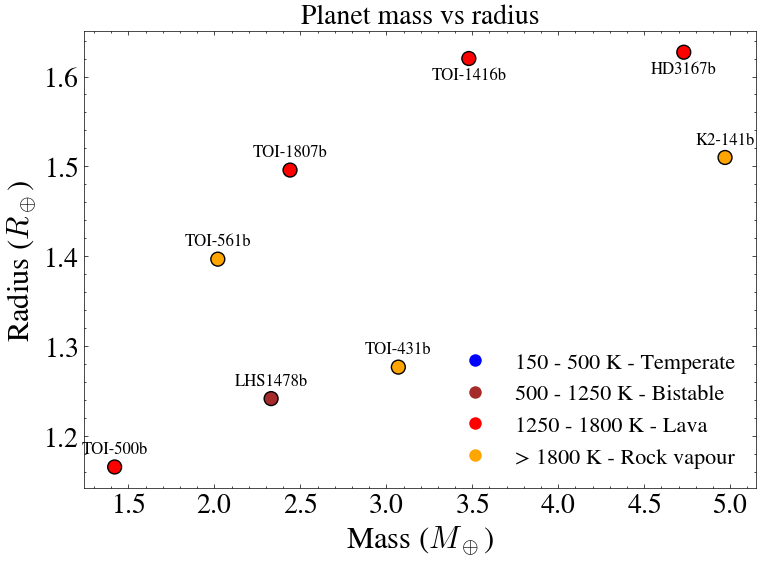

In [5]:
plt.style.use(['science', 'no-latex'])

#set color based on equilibrium temperature
planet_equilibrium_temperature = [1500, 2000, 750, 2000, 1500, 2000, 1500, 1500] #K, to be fixed according to archive data

if len(planet_equilibrium_temperature) == len(planet_names):
    colors = []
    for T in planet_equilibrium_temperature:
        if T < 500:
            colors.append('blue')
        elif 500 <= T < 1250:
            colors.append('brown')
        elif 1250 <= T < 1800:
            colors.append('red')
        else:
            colors.append('orange')

# scatter plot of planet mass vs radius
fig = figure(figsize=(8, 6))
frame = fig.add_subplot(1, 1, 1)

frame.scatter(planet_masses, planet_radius, color=colors, s=100, edgecolor='black')

for i, name in enumerate(planet_names):
    if name != "TOI1416" and name != "HD3167":
        frame.annotate(planet_fullnames[i], (planet_masses[i], planet_radius[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12)
    else:
        #annotate them but below the point instead of above it
        frame.annotate(planet_fullnames[i], (planet_masses[i], planet_radius[i]), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=12)
#create label for colors
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='150 - 500 K - Temperate', markerfacecolor='blue', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='500 - 1250 K - Bistable', markerfacecolor='brown', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='1250 - 1800 K - Lava', markerfacecolor='red', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='> 1800 K - Rock vapour', markerfacecolor='orange', markersize=10)]


frame.set_title('Planet mass vs radius',fontsize=20)
frame.set_xlabel(r'Mass ($M_\oplus$)')
frame.set_ylabel(r'Radius ($R_\oplus$)')

frame.tick_params(axis='both', which='major')

frame.grid()
frame.legend(handles=legend_elements, loc='lower right')
#tight layout
plt.tight_layout()
savefig('thesis-plots/planet_mass_radius_scatter.pdf', bbox_inches='tight')
show()

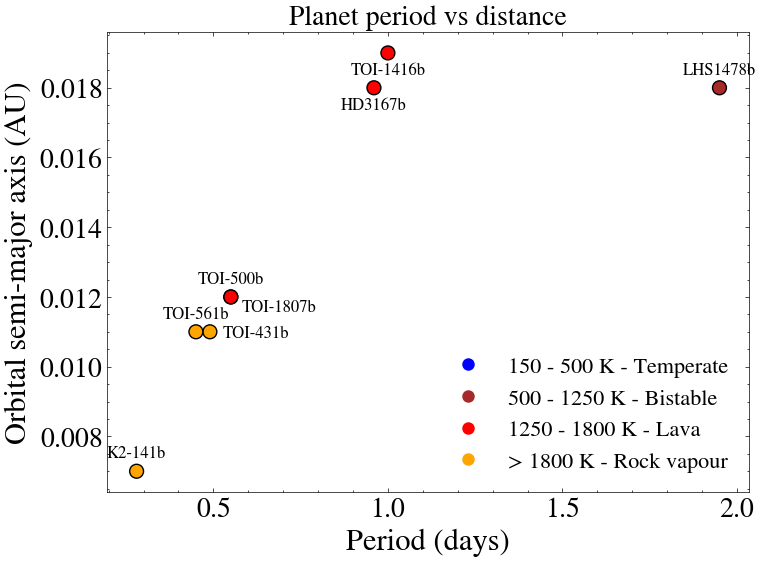

In [6]:
# scatter plot of planet mass vs radius

fig = figure(figsize=(8, 6))
frame = fig.add_subplot(1, 1, 1)

frame.scatter(planet_period, planet_distances, color=colors, s=100, edgecolor='black')

for i, name in enumerate(planet_names):
    if name != "TOI1416" and name != "HD3167" and name != "LHS1478" and name != "TOI431" and name != "TOI1807":
        frame.annotate(planet_fullnames[i], (planet_period[i], planet_distances[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12)
    elif name == "LHS1478":
        frame.annotate(planet_fullnames[i], (planet_period[i], planet_distances[i]), textcoords="offset points", xytext=(-7,10), ha='center', fontsize=12)
    elif name == "TOI431":
        frame.annotate(planet_fullnames[i], (planet_period[i], planet_distances[i]), textcoords="offset points", xytext=(33,-4), ha='center', fontsize=12)
    elif name == "TOI1807":
        frame.annotate(planet_fullnames[i], (planet_period[i], planet_distances[i]), textcoords="offset points", xytext=(35,-10), ha='center', fontsize=12)
    else:
        #annotate them but below the point instead of above it
        frame.annotate(planet_fullnames[i], (planet_period[i], planet_distances[i]), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=12)

#create label for colors
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='150 - 500 K - Temperate', markerfacecolor='blue', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='500 - 1250 K - Bistable', markerfacecolor='brown', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='1250 - 1800 K - Lava', markerfacecolor='red', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='> 1800 K - Rock vapour', markerfacecolor='orange', markersize=10)]


frame.set_title('Planet period vs distance',fontsize=20)
frame.set_xlabel(r'Period (days)')
frame.set_ylabel(r'Orbital semi-major axis (AU)')

frame.tick_params(axis='both', which='major')

frame.grid()
frame.legend(handles=legend_elements, loc='lower right')
#tight layout
plt.tight_layout()
savefig('thesis-plots/planet_period_distance_scatter.pdf', bbox_inches='tight')
show()

# Validation plots

In [7]:
#for all planets except toi-431, lhs1478 and k2141

with open('bulk_density_evolution.pkl', 'rb') as f:
    data_all = pickle.load(f)

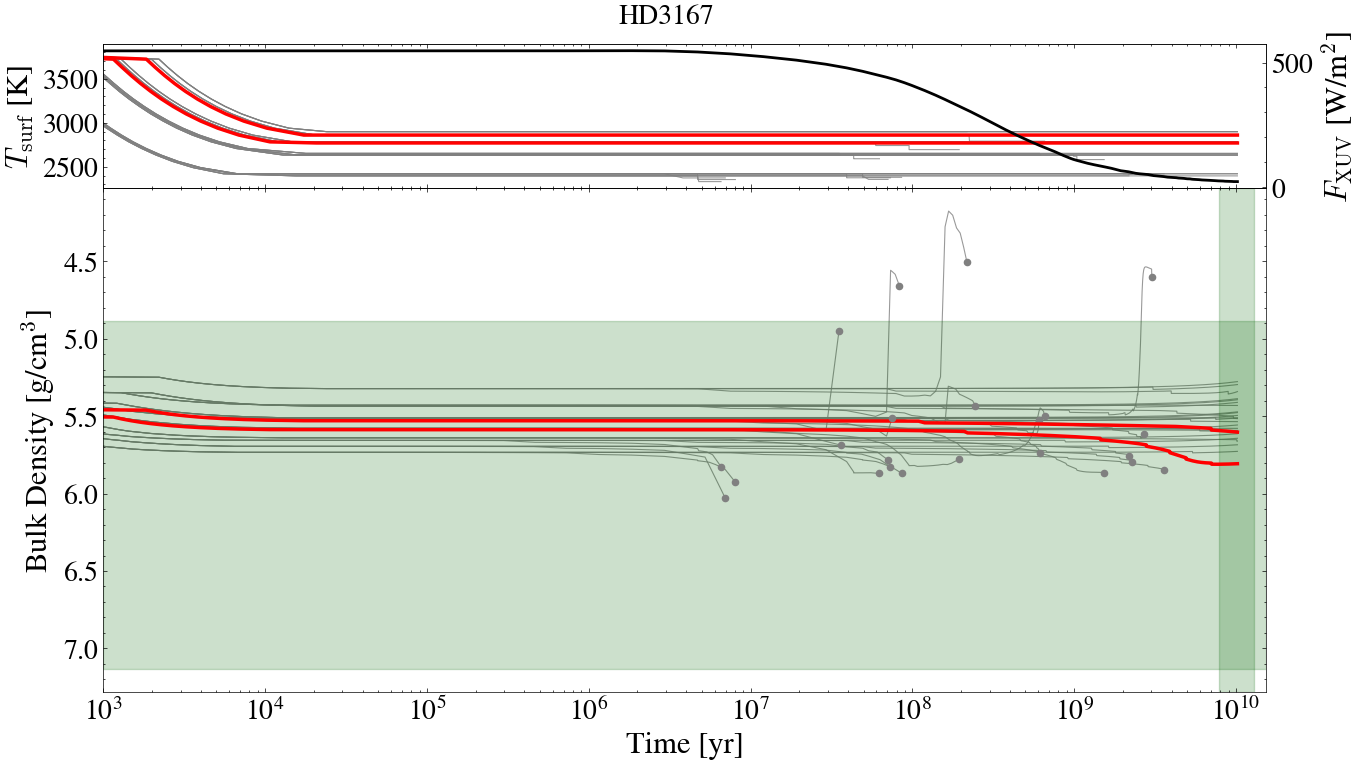

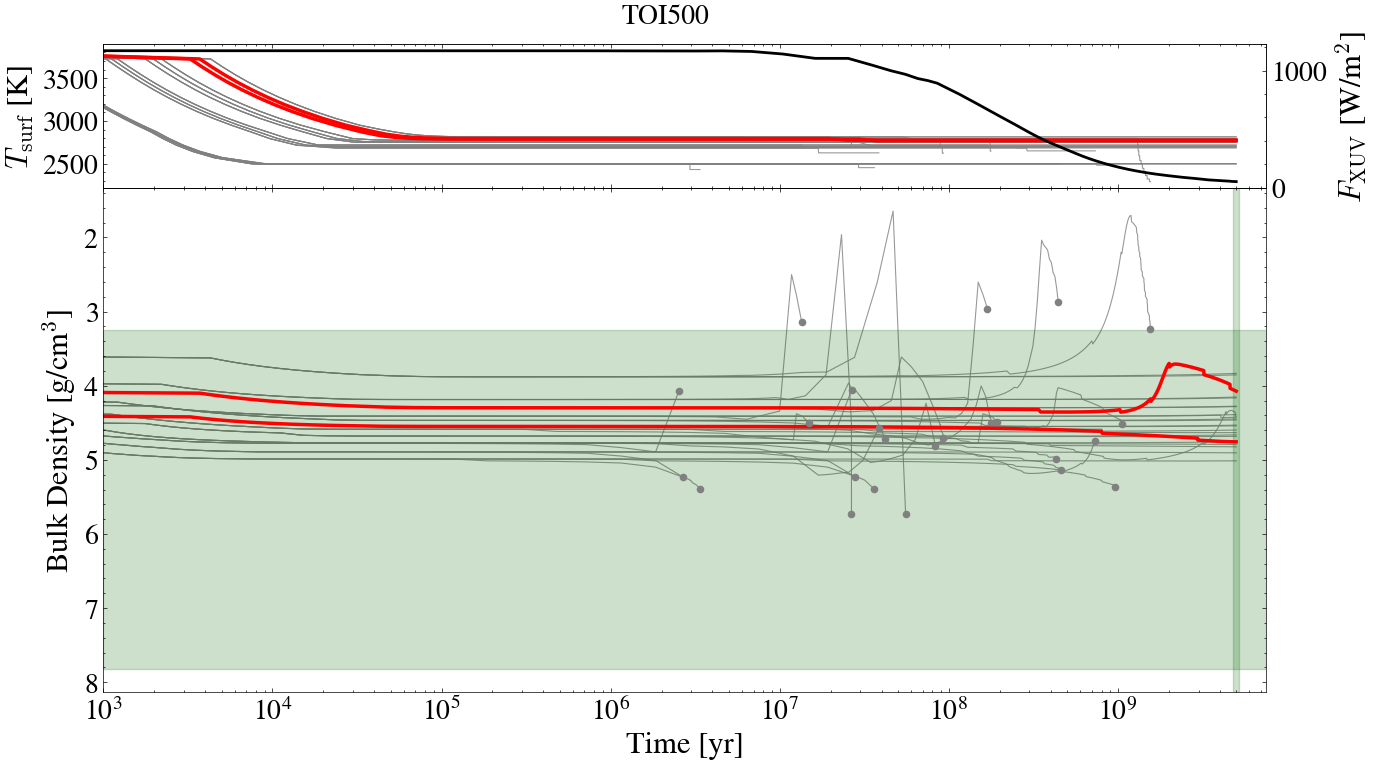

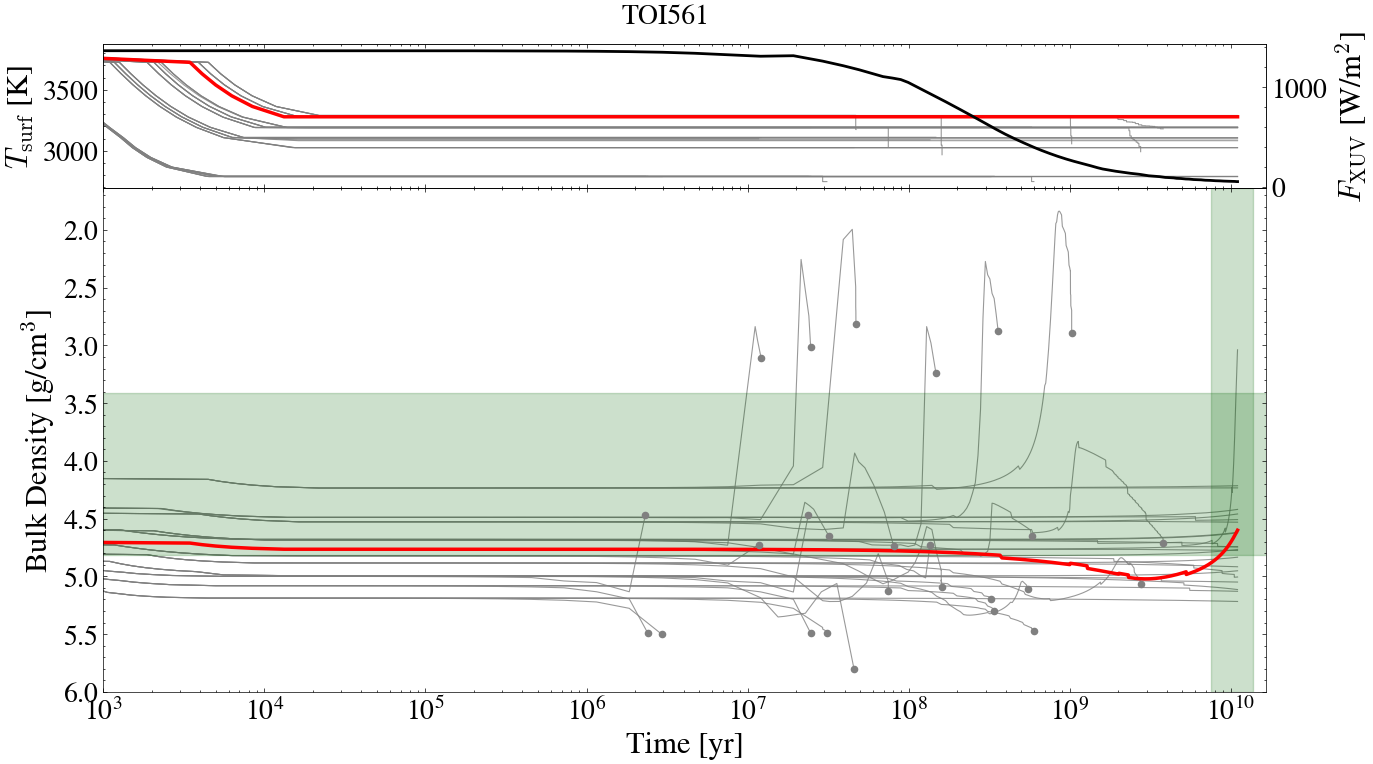

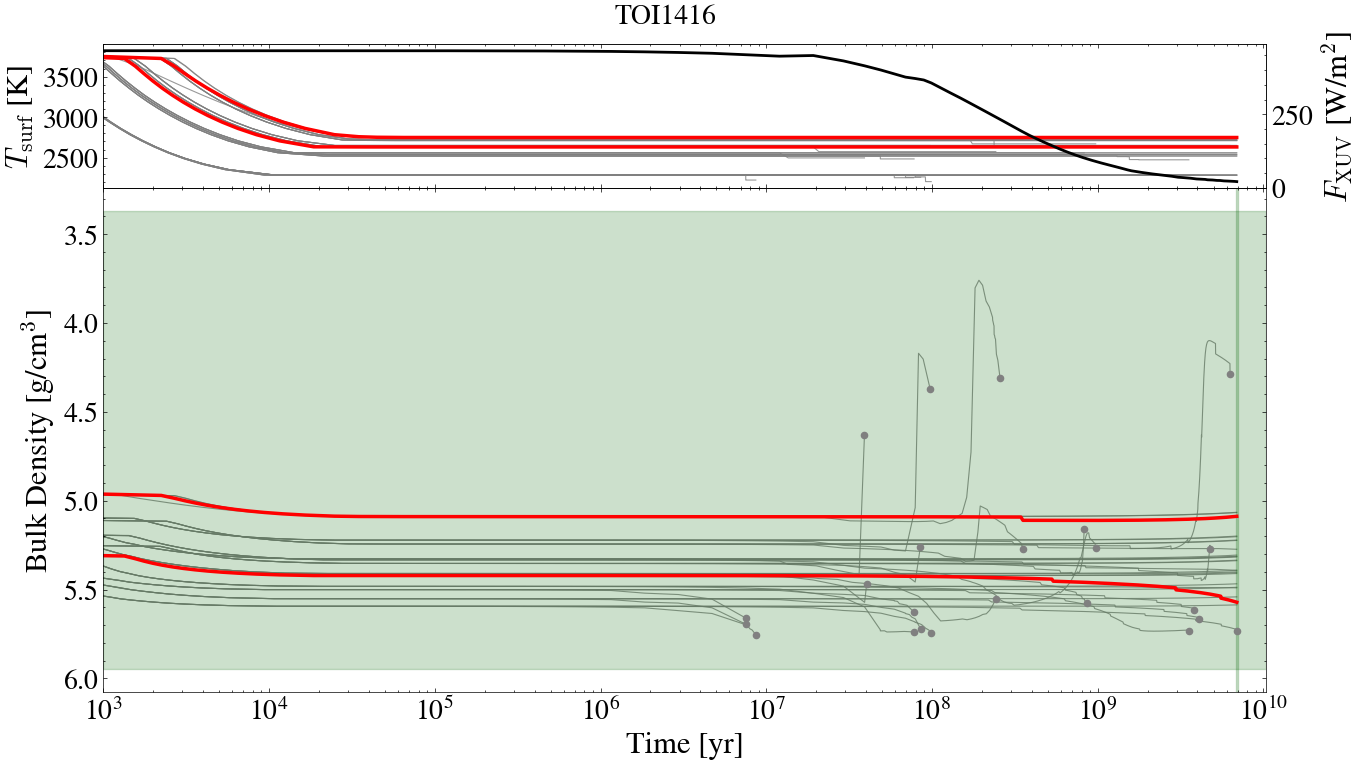

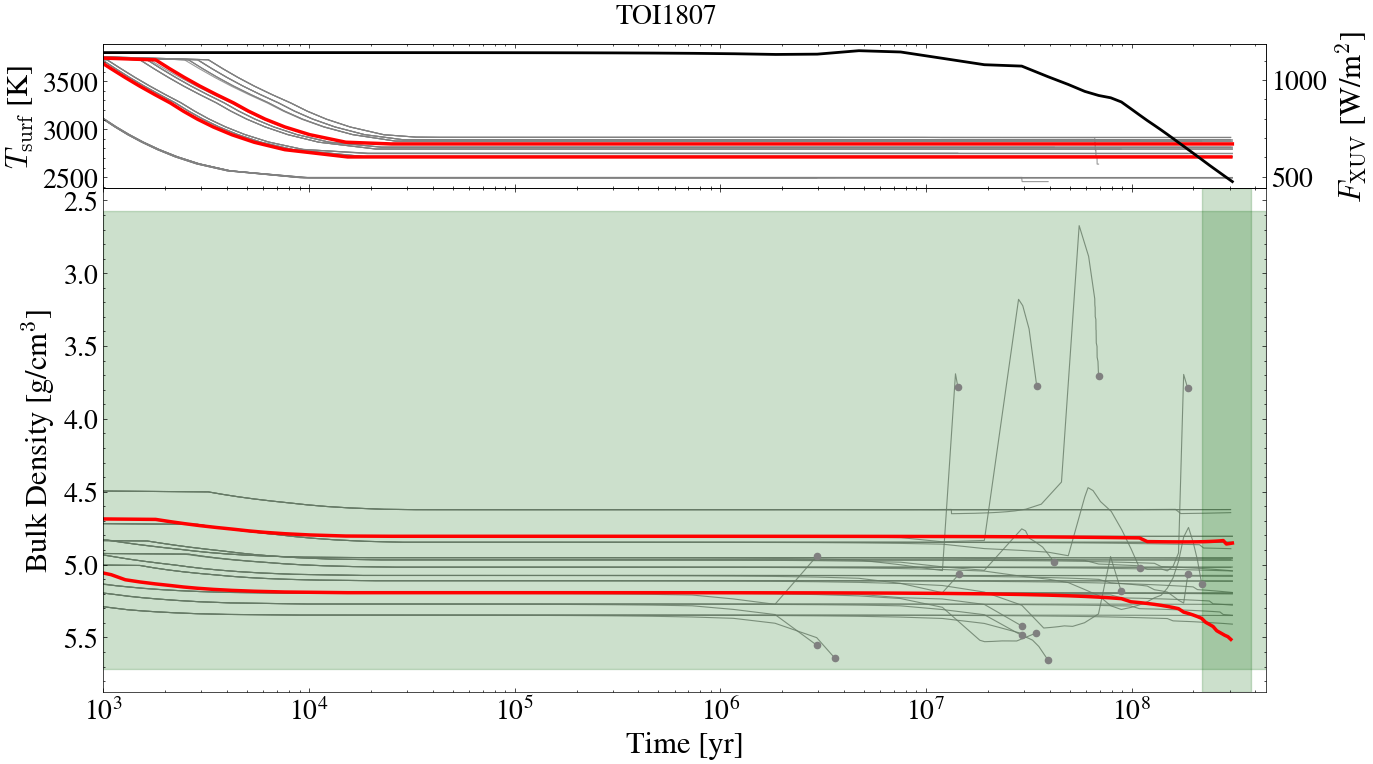

In [65]:
# Okabe-Ito colorblind-friendly palette for H_oceans
colors = {
    1.0:  '#0072B2',  # blue
    5.0:  '#009E73',  # green
    10.0: '#E69F00',  # orange
    20.0: '#D55E00',  # vermillion
    30.0: '#CC79A7',  # pink
}

h_ocean_values = [1.0, 5.0, 10.0, 20.0]
cmap = ListedColormap([colors[h] for h in h_ocean_values])
bounds = [0, 2, 8, 12, 28]
norm = BoundaryNorm(bounds, cmap.N)

# Cases to highlight per planet — all others will be gray
# Use planet names as keys, value is a list of case strings
highlighted_cases = {
    "HD3167":  ["case_000034", "case_000046"],
    "TOI500":  ["case_000042", "case_000046"],
    "TOI561":  ["case_000046"],
    "TOI1416": ["case_000034", "case_000038"],
    "TOI1807": ["case_000022", "case_000026"],
}

for planet, simulations in data_all.items():
    fig = figure(figsize=(15, 8))
    fig.suptitle(rf"{planet}",fontsize=20, y=0.98)

    frame   = fig.add_axes([0.125, 0.12, 0.775, 0.63])
    ax_temp = fig.add_axes([0.125, 0.75, 0.775, 0.18], sharex=frame)


    ax_temp.set_ylabel(r'$T_\mathrm{surf}$ [K]')
    ax_temp.set_xscale('log')
    ax_temp.tick_params(labelbottom=False)

    age      = star_age[planet_names.index(f"{planet}")]
    age_min  = star_age_min[planet_names.index(f"{planet}")]
    age_max  = star_age_max[planet_names.index(f"{planet}")]
    bd       = bulk_density_avg[planet_names.index(f"{planet}")]
    bd_min   = bulk_density_min[planet_names.index(f"{planet}")]
    bd_max   = bulk_density_max[planet_names.index(f"{planet}")]

    longest_sim = None
    max_time = -np.inf
    highlight = highlighted_cases.get(planet, [])

    for sim in simulations:
        is_highlighted = sim["case"] in highlight
        color   = 'red' if is_highlighted else 'gray'
        lw      = 2.5 if is_highlighted else 0.8
        zorder  = 2 if is_highlighted else 1

        frame.plot(sim["x"], sim["y"]/1000,
                   color=color, linestyle='solid', alpha=1.0 if is_highlighted else 0.8, linewidth=lw, zorder=zorder)
        if sim["x"][-1] < age:
            frame.scatter(sim["x"][-1], sim["y"][-1]/1000, color=color, s=20, zorder=zorder+1)
        ax_temp.plot(sim["x"], sim["t_surf"],
                     color=color, linestyle='solid', alpha=1.0 if is_highlighted else 0.8, linewidth=lw, zorder=zorder)
        ax_temp.grid(False)

        if sim["x"][-1] > max_time:
            max_time = sim["x"][-1]
            longest_sim = sim

    if longest_sim is not None:
        ax2 = ax_temp.twinx()
        ax2.grid(False)
        ax2.plot(longest_sim["x"], longest_sim["F_xuv"], color='black', alpha=1.0, linewidth=2.0)
        ax2.set_ylabel(r'$F_\mathrm{XUV}$ [W/m$^2$]')
        ax2.tick_params(axis='both', which='major')

    #frame.errorbar(age, bd,
    #               xerr=([abs(age_min-age)], [abs(age_max-age)]),
    #               yerr=([abs(bd_min-bd)],   [abs(bd_max-bd)]),
    #               fmt='o', color='black', ecolor='black', elinewidth=3, capsize=5, zorder=5)
    
    #instead of error bars, create shaded regions for age and bulk density uncertainties
    frame.axvspan(age_min, age_max, color='darkgreen', alpha=0.2, zorder=1)
    frame.axhspan(bd_min, bd_max, color='darkgreen', alpha=0.2, zorder=1)

    #frame.scatter(age, bd, color='red', zorder=6)

    frame.set_xlabel('Time [yr]')
    frame.set_ylabel(r'Bulk Density [g/cm$^3$]')
    frame.set_xscale('log')
    frame.tick_params(axis='both', which='major')
    frame.invert_yaxis()
    frame.set_xlim(1e3, age*1.5)
    #turn off grid
    frame.grid(False)
    if planet != "TOI431" and planet != "lhs1478" and planet != "K2141":
        savefig(f"thesis-plots/{planet}_bulk_density.pdf", format='pdf')
        show()
    plt.close()


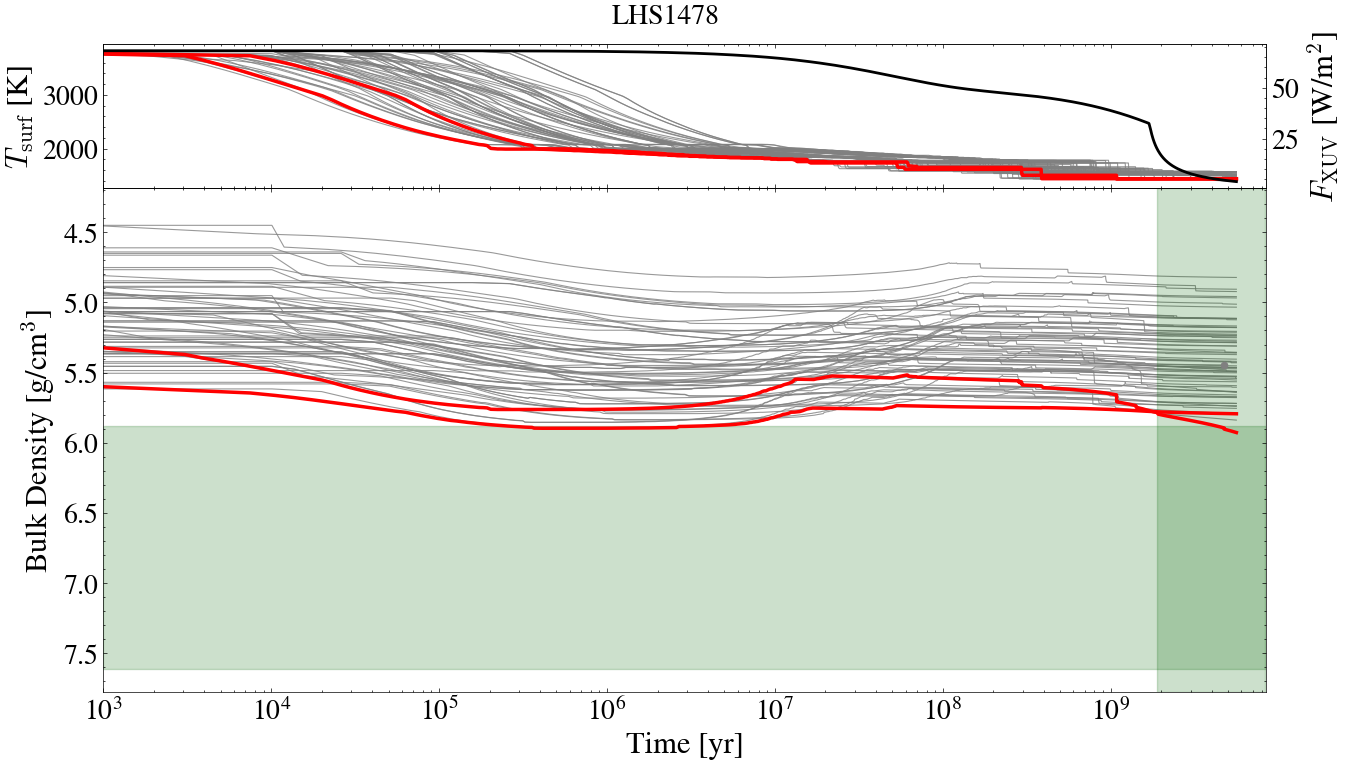

In [67]:
# plot for LHS1478 using bulk_density_evolution_LHS.pkl
with open('bulk_density_evolution_LHS.pkl', 'rb') as f:
    data_lhs = pickle.load(f)

highlighted_cases_lhs = ["case_000001", "case_000011"]

planet = "lhs1478"
simulations = data_lhs[planet]

fig = figure(figsize=(15, 8))
fig.suptitle(rf"LHS1478", fontsize=20, y=0.98)

frame   = fig.add_axes([0.125, 0.12, 0.775, 0.63])
ax_temp = fig.add_axes([0.125, 0.75, 0.775, 0.18], sharex=frame)


ax_temp.set_ylabel(r'$T_\mathrm{surf}$ [K]')
ax_temp.set_xscale('log')
ax_temp.tick_params(labelbottom=False)

age      = star_age[planet_names.index(planet)]
age_min  = star_age_min[planet_names.index(planet)]
age_max  = star_age_max[planet_names.index(planet)]
bd       = bulk_density_avg[planet_names.index(planet)]
bd_min   = bulk_density_min[planet_names.index(planet)]
bd_max   = bulk_density_max[planet_names.index(planet)]

longest_sim = None
max_time = -np.inf

for sim in simulations:
    is_highlighted = sim["case"] in highlighted_cases_lhs
    color   = 'red' if is_highlighted else 'gray'
    lw      = 2.5 if is_highlighted else 0.8
    zorder  = 2 if is_highlighted else 1
    alpha   = 1.0 if is_highlighted else 0.8

    frame.plot(sim["x"], sim["y"]/1000,
               color=color, linestyle='solid', alpha=alpha, linewidth=lw, zorder=zorder)
    if sim["x"][-1] < age:
        frame.scatter(sim["x"][-1], sim["y"][-1]/1000, color=color, s=20, zorder=zorder+1)
    ax_temp.plot(sim["x"], sim["t_surf"],
                 color=color, linestyle='solid', alpha=alpha, linewidth=lw, zorder=zorder)
    ax_temp.grid(False)

    if sim["x"][-1] > max_time:
        max_time = sim["x"][-1]
        longest_sim = sim

if longest_sim is not None:
    ax2 = ax_temp.twinx()
    ax2.plot(longest_sim["x"], longest_sim["F_xuv"], color='black', alpha=1.0, linewidth=2.0)
    ax2.set_ylabel(r'$F_\mathrm{XUV}$ [W/m$^2$]')
    ax2.tick_params(axis='both', which='major')
    ax2.grid(False)

#frame.errorbar(age, bd,
#               xerr=([abs(age_min-age)], [abs(age_max-age)]),
#               yerr=([abs(bd_min-bd)],   [abs(bd_max-bd)]),
#               fmt='o', color='black', ecolor='black', elinewidth=3, capsize=5, zorder=5)
#frame.scatter(age, bd, color='red', zorder=6)
#instead of error bars, create shaded regions for age and bulk density uncertainties
frame.axvspan(age_min, age_max, color='darkgreen', alpha=0.2, zorder=1)
frame.axhspan(bd_min, bd_max, color='darkgreen', alpha=0.2, zorder=1)


frame.set_xlabel('Time [yr]')
frame.set_ylabel(r'Bulk Density [g/cm$^3$]')
frame.set_xscale('log')
frame.tick_params(axis='both', which='major')
frame.invert_yaxis()
frame.set_xlim(1e3, age*1.5)
frame.grid(False)

savefig(f"thesis-plots/{planet}_bulk_density.pdf", format='pdf')
show()
plt.close()


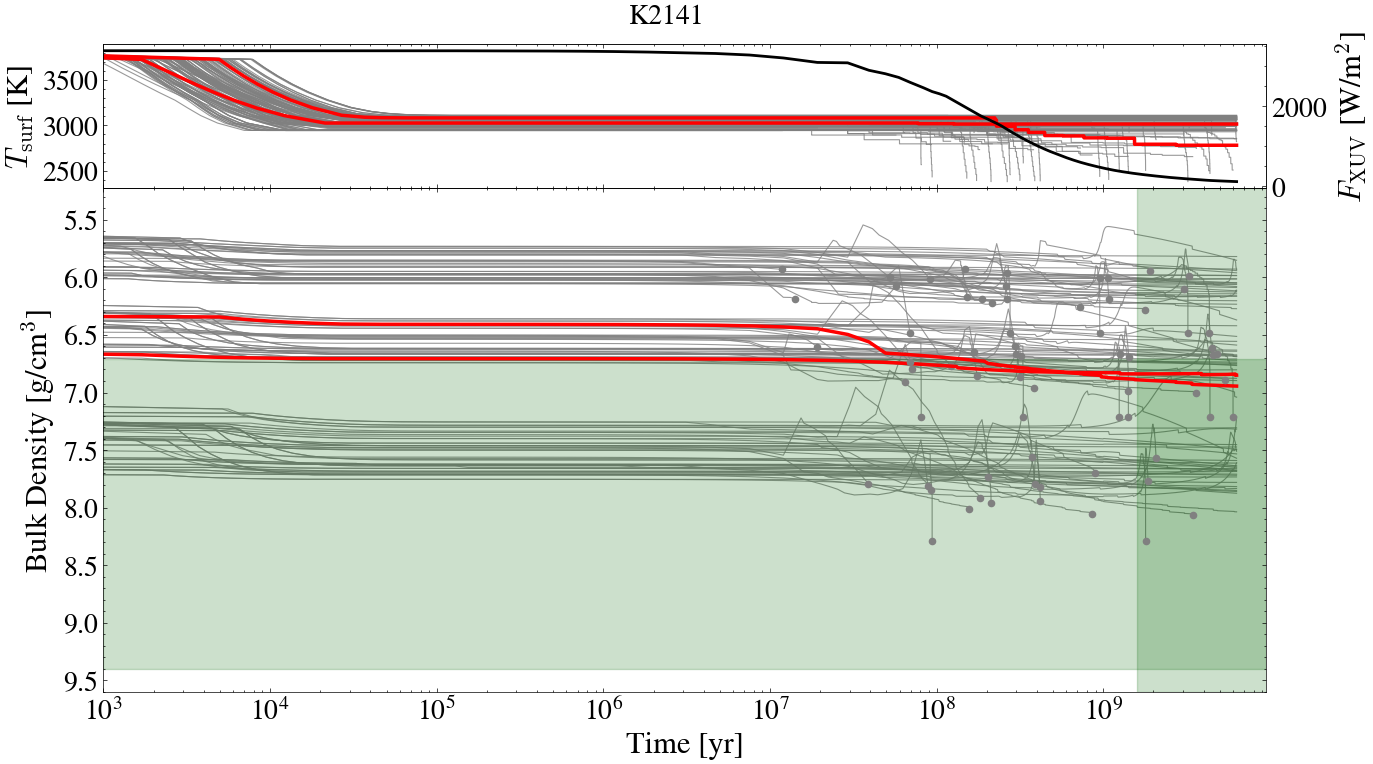

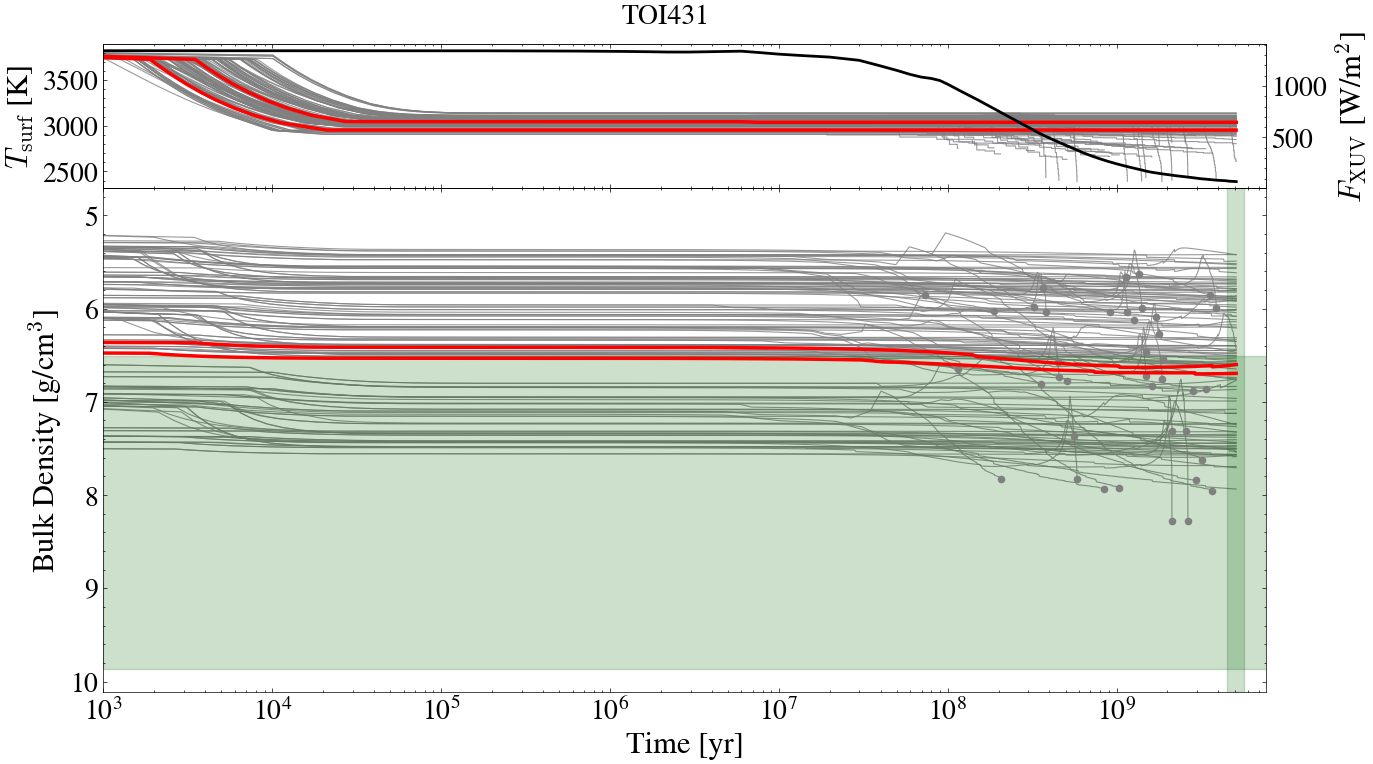

In [68]:
# plot for TOI431 and K2141 using bulk_density_evolution_K2TOI431.pkl
with open('bulk_density_evolution_K2TOI431.pkl', 'rb') as f:
    data_k2toi = pickle.load(f)

highlighted_cases_k2toi = {
    "TOI431": ["case_000034", "case_000082"],
    "K2141":  ["case_000088", "case_000124"],
}

for planet, simulations in data_k2toi.items():
    if planet not in highlighted_cases_k2toi:
        continue
    fig = figure(figsize=(15, 8))
    fig.suptitle(rf"{planet}", fontsize=20, y=0.98)

    frame   = fig.add_axes([0.125, 0.12, 0.775, 0.63])
    ax_temp = fig.add_axes([0.125, 0.75, 0.775, 0.18], sharex=frame)

    ax_temp.set_ylabel(r'$T_\mathrm{surf}$ [K]')
    ax_temp.set_xscale('log')
    ax_temp.tick_params(labelbottom=False)

    age      = star_age[planet_names.index(planet)]
    age_min  = star_age_min[planet_names.index(planet)]
    age_max  = star_age_max[planet_names.index(planet)]
    bd       = bulk_density_avg[planet_names.index(planet)]
    bd_min   = bulk_density_min[planet_names.index(planet)]
    bd_max   = bulk_density_max[planet_names.index(planet)]

    highlight = highlighted_cases_k2toi.get(planet, [])
    longest_sim = None
    max_time = -np.inf

    for sim in simulations:
        is_highlighted = sim["case"] in highlight
        color   = 'red' if is_highlighted else 'gray'
        lw      = 2.5 if is_highlighted else 0.8
        zorder  = 2 if is_highlighted else 1
        alpha   = 1.0 if is_highlighted else 0.8

        frame.plot(sim["x"], sim["y"]/1000,
                   color=color, linestyle='solid', alpha=alpha, linewidth=lw, zorder=zorder)
        if sim["x"][-1] < age:
            frame.scatter(sim["x"][-1], sim["y"][-1]/1000, color=color, s=20, zorder=zorder+1)
        ax_temp.plot(sim["x"], sim["t_surf"],
                     color=color, linestyle='solid', alpha=alpha, linewidth=lw, zorder=zorder)
        ax_temp.grid(False)

        if sim["x"][-1] > max_time:
            max_time = sim["x"][-1]
            longest_sim = sim

    if longest_sim is not None:
        ax2 = ax_temp.twinx()
        ax2.plot(longest_sim["x"], longest_sim["F_xuv"], color='black', alpha=1.0, linewidth=2.0)
        ax2.set_ylabel(r'$F_\mathrm{XUV}$ [W/m$^2$]')
        ax2.tick_params(axis='both', which='major')
        ax2.grid(False)

    #frame.errorbar(age, bd,
    #               xerr=([abs(age_min-age)], [abs(age_max-age)]),
    #               yerr=([abs(bd_min-bd)],   [abs(bd_max-bd)]),
    #               fmt='o', color='red', ecolor='black', elinewidth=3, capsize=5, zorder=5)
    #frame.scatter(age, bd, color='red', zorder=6)
    #instead of error bars, create shaded regions for age and bulk density uncertainties
    frame.axvspan(age_min, age_max, color='darkgreen', alpha=0.2, zorder=1)
    frame.axhspan(bd_min, bd_max, color='darkgreen', alpha=0.2, zorder=1)


    frame.set_xlabel('Time [yr]')
    frame.set_ylabel(r'Bulk Density [g/cm$^3$]')
    frame.set_xscale('log')
    frame.tick_params(axis='both', which='major')
    frame.invert_yaxis()
    frame.set_xlim(1e3, age*1.5)
    frame.grid(False)
    
    savefig(f"thesis-plots/{planet}_bulk_density.pdf", format='pdf')
    show()
    plt.close()


# Atmosphere composition plots

In [ ]:
with open('bulk_density_evolution.pkl', 'rb') as f:
    data_all = pickle.load(f)

with open('bulk_density_evolution_LHS.pkl', 'rb') as f:
    data_lhs = pickle.load(f)

with open('bulk_density_evolution_K2TOI431.pkl', 'rb') as f:
    data_k2toi = pickle.load(f)

# for each pickle go through each planet and extract the final vmrs of the highlighted cases
final_vmr_data = {}
for name in planet_names:
    final_vmr_data[name] = {}
    if name == "lhs1478":
        simulations = data_lhs[name]
        highlight = highlighted_cases_lhs
        for sim in simulations:
            if sim["case"] in highlight:
                final_vmr_data[name][sim["case"]] = {
                    "H2O": float(sim['h2o_vmr_final']),
                    "CO2": float(sim['co2_vmr_final']),
                    "O2": float(sim['o2_vmr_final']),
                    "N2": float(sim['n2_vmr_final']),
                    "H2": float(sim['h2_vmr_final']),
                    "SO2": float(sim['so2_vmr_final']),
                    "CH4": float(sim['ch4_vmr_final']),
                    "CO": float(sim['co_vmr_final']),
                    "NH3": float(sim['nh3_vmr_final']),
                    "S2": float(sim['s2_vmr_final']),
                    "H2S": float(sim['h2s_vmr_final']),
                    "surface_pressure": float(sim['p_surf']),
                }
    elif name == 'TOI431' or name == 'K2141':
        simulations = data_k2toi[name]
        highlight = highlighted_cases_k2toi.get(name, [])
        for sim in simulations:
            if sim["case"] in highlight:
                final_vmr_data[name][sim["case"]] = {
                    "H2O": float(sim['h2o_vmr_final']),
                    "CO2": float(sim['co2_vmr_final']),
                    "O2": float(sim['o2_vmr_final']),
                    "N2": float(sim['n2_vmr_final']),
                    "H2": float(sim['h2_vmr_final']),
                    "SO2": float(sim['so2_vmr_final']),
                    "CH4": float(sim['ch4_vmr_final']),
                    "CO": float(sim['co_vmr_final']),
                    "NH3": float(sim['nh3_vmr_final']),
                    "S2": float(sim['s2_vmr_final']),
                    "H2S": float(sim['h2s_vmr_final']),
                    "surface_pressure": float(sim['p_surf'])
                }
    else:
        simulations = data_all[name]
        highlight = highlighted_cases.get(name, [])
        for sim in simulations:
            if sim["case"] in highlight:
                final_vmr_data[name][sim["case"]] = {
                    "H2O": float(sim['h2o_vmr_final']),
                    "CO2": float(sim['co2_vmr_final']),
                    "O2": float(sim['o2_vmr_final']),
                    "N2": float(sim['n2_vmr_final']),
                    "H2": float(sim['h2_vmr_final']),
                    "SO2": float(sim['so2_vmr_final']),
                    "CH4": float(sim['ch4_vmr_final']),
                    "CO": float(sim['co_vmr_final']),
                    "NH3": float(sim['nh3_vmr_final']),
                    "S2": float(sim['s2_vmr_final']),
                    "H2S": float(sim['h2s_vmr_final']),
                    "surface_pressure": float(sim['p_surf'])
                }
#save final_vmr_data to a new pickle
with open('final_vmr_data.pkl', 'wb') as f:
    pickle.dump(final_vmr_data, f)

In [21]:
mu_h2O = 18.01528
mu_co2 = 44.01
mu_o2 = 32.00
mu_n2 = 28.0134
mu_h2 = 2.01588
mu_so2 = 64.066
mu_ch4 = 16.04
mu_co = 28.01
mu_nh3 = 17.031
mu_s2 = 64.14
mu_h2s = 34.08

#for all simulations, calculate the mean molecular weight of the atmosphere using the final vmrs and the molecular weights of the species, and save it to a new dictionary
mean_molecular_weight_data = {}
for planet, cases in final_vmr_data.items():
    mean_molecular_weight_data[planet] = {}
    for case, vmrs in cases.items():
        mean_molecular_weight = (vmrs["H2O"] * mu_h2O + vmrs["CO2"] * mu_co2 + vmrs["O2"] * mu_o2 + vmrs["N2"] * mu_n2 + vmrs["H2"] * mu_h2 + vmrs["SO2"] * mu_so2 + vmrs["CH4"] * mu_ch4 + vmrs["CO"] * mu_co + vmrs["NH3"] * mu_nh3 + vmrs["S2"] * mu_s2 + vmrs["H2S"] * mu_h2s) / (vmrs["H2O"] + vmrs["CO2"] + vmrs["O2"] + vmrs["N2"] + vmrs["H2"] + vmrs["SO2"] + vmrs["CH4"] + vmrs["CO"] + vmrs["NH3"] + vmrs["S2"] + vmrs["H2S"])
        mean_molecular_weight_data[planet][case] = mean_molecular_weight

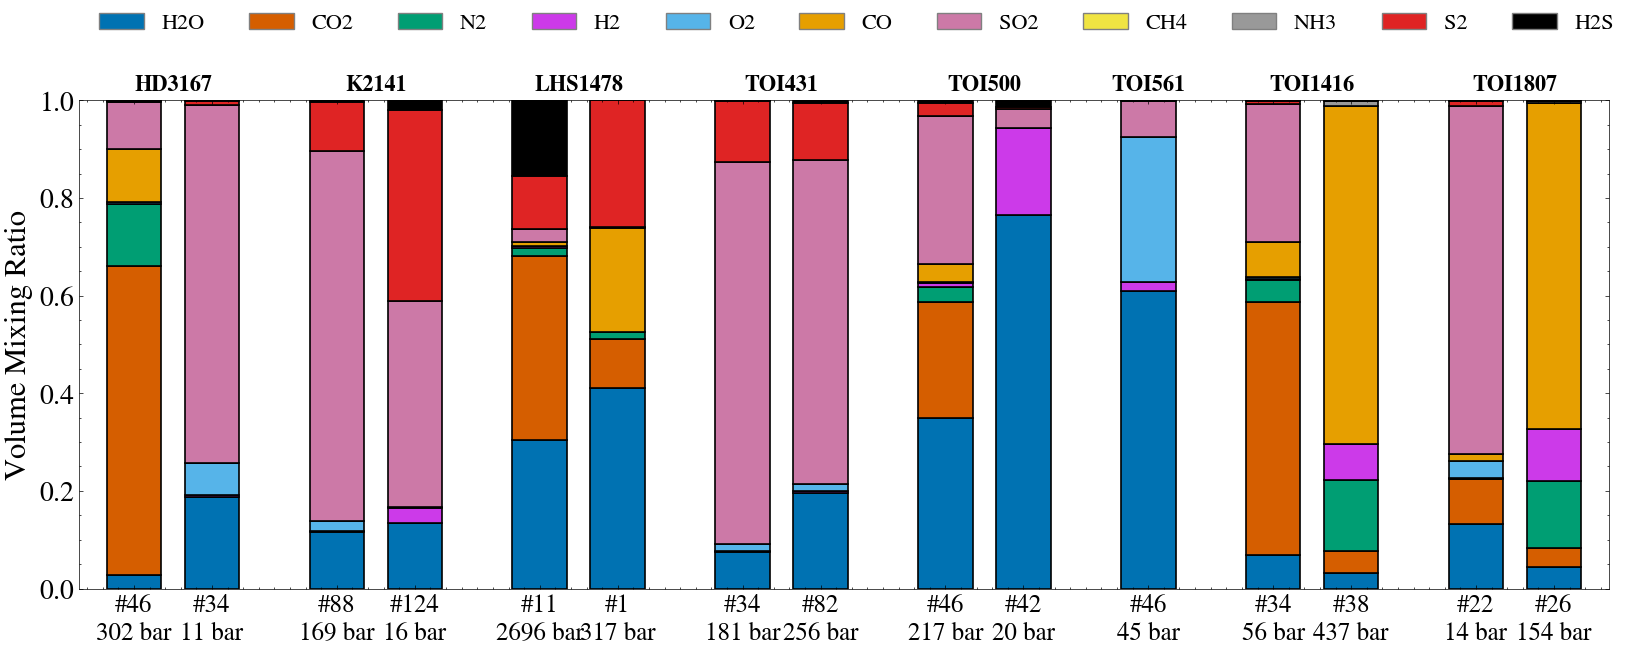

In [12]:
# Atmospheric composition bar chart for all highlighted cases
molecules = ["H2O", "CO2", "N2","H2", "O2", "CO", "SO2", "CH4", "NH3", "S2", "H2S"]

# Okabe-Ito + extras for molecules
mol_colors = {
    "H2O":  "#0072B2",
    "CO2":  "#D55E00",
    "N2":   "#009E73",
    "H2":   "#CC3AE9",
    "O2":   "#56B4E9",
    "CO":   "#E69F00",
    "SO2":  "#CC79A7",
    "CH4":  "#F0E442",
    "NH3":  "#999999",
    "S2":   "#DF2424",
    "H2S":  "#000000"
}

# collect all bars in order: for each planet, one bar per highlighted case
bar_labels = []   # x-tick labels: "case_XXXXXX\nP=XXX bar"
bar_planet = []   # which planet each bar belongs to (for grouping spacing)
bar_vmrs   = []   # list of dicts {molecule: vmr}

for planet in planet_names:
    cases = final_vmr_data.get(planet, {})
    for case, vals in cases.items():
        case_num = int(case.split("_")[-1])
        bar_labels.append(f"#{case_num}\n{vals['surface_pressure']:.0f} bar")
        bar_planet.append(planet)
        bar_vmrs.append(vals)

# build x positions with a gap between planets
x_positions = []
planet_centers = {}
x = 0
prev_planet = None
for i, planet in enumerate(bar_planet):
    if prev_planet is not None and planet != prev_planet:
        x += 0.6  # extra gap between planet groups
    x_positions.append(x)
    x += 1.0
    prev_planet = planet

# compute planet label center positions
for planet in planet_names:
    idxs = [i for i, p in enumerate(bar_planet) if p == planet]
    if idxs:
        planet_centers[planet] = (x_positions[idxs[0]] + x_positions[idxs[-1]]) / 2

fig, ax = plt.subplots(figsize=(max(14, len(bar_labels)*1.2), 7))
ax.grid(False)

for i, (xpos, vmrs) in enumerate(zip(x_positions, bar_vmrs)):
    bottom = 0.0
    for mol in molecules:
        val = vmrs.get(mol, 0.0)
        if val > 0:
            ax.bar(xpos, val, bottom=bottom, width=0.7,
                   color=mol_colors[mol], edgecolor='black', linewidth=1.2)
            bottom += val

# x-axis: case name + pressure below, planet name above as group label
ax.set_xticks(x_positions)
ax.set_xticklabels(bar_labels, ha='center', fontsize=rcParams['xtick.labelsize']-2)

# planet name annotations above the bars
ymax = ax.get_ylim()[1]
for planet, cx in planet_centers.items():
    ax.annotate(planet.upper() if planet == 'lhs1478' else planet, xy=(cx, 1.02), xycoords=('data', 'axes fraction'),
                ha='center', fontweight='bold')

# legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=mol_colors[m], edgecolor='gray', label=m) for m in molecules]
ax.legend(handles=legend_handles, loc='upper left', ncol=len(molecules),
           bbox_to_anchor=(0.0, 1.22), frameon=False)

ax.set_ylabel('Volume Mixing Ratio')
ax.set_ylim(0, 1)
ax.set_xlim(x_positions[0] - 0.7, x_positions[-1] + 0.7)

plt.tight_layout()
savefig('thesis-plots/atmosphere_composition.pdf', format='pdf')
show()
plt.close()


In [ ]:
cases = ["46", "34", "88", "124", "1", "11",  ]

# Table of resulting atmospheres

In [40]:
results = pd.read_csv('combined_nightside_results.csv',index_col=0)
#DROP rcolumns 8,9,10,11

results.drop(results.columns[8:12], axis=1, inplace=True)
results

,Planet,Surface Pressure [bar],Atmospheric Components,Hydrogen Inventory [H oceans],Redox State,Integration Time (hours),Number of observations,Observations with bb fit
0,HD3167,10.902882,"SO2, H2O",H10,IW4,345.60,15,18.0
1,HD3167,301.889080,"CO2, N2",H20,IW4,299.52,13,15.0
2,K2141,169.221367,"SO2, H2O",H20,IW4,53.76,8,8.0
3,K2141,16.028394,"SO2, S2",H30,IW2,53.76,8,8.0
4,LHS1478,317.212366,"H2O, S2",H05,IW0,468000.00,10000,9850.0
5,LHS1478,2693.216197,"CO2, H2O",H05,IW4,468000.00,10000,9850.0
7,TOI1416,55.970885,"CO2, SO2",H10,IW4,1176.00,49,53.0
8,TOI1416,437.019741,"CO, N2",H20,IW0,840.00,35,37.0
9,TOI1807,153.474293,"CO, N2",H10,IW0,277.20,21,21.0
10,TOI1807,13.566413,"SO2, H2O",H5,IW4,422.40,32,32.0


In [22]:
mean_molecular_weight_data

{'HD3167': {'case_000046': 41.45234826886619,
  'case_000034': 53.05247271804008},
 'K2141': {'case_000088': 57.86251080939287, 'case_000124': 55.35146444895296},
 'lhs1478': {'case_000011': 36.81364559001949,
  'case_000001': 34.93206623831668},
 'TOI431': {'case_000034': 60.003437538727596,
  'case_000082': 54.13529196559052},
 'TOI500': {'case_000046': 39.99649201743114,
  'case_000042': 17.389556736774118},
 'TOI561': {'case_000046': 25.322500084774234},
 'TOI1416': {'case_000034': 46.02444543566947,
  'case_000038': 26.34706146636201},
 'TOI1807': {'case_000022': 54.3553672988508,
  'case_000026': 25.394483759928306}}

In [31]:
atmos_table = pd.DataFrame({
    "Planet": results["Planet"],
    "Case": 0,
    "Hydrogen Inventory [H oceans]": results["Hydrogen Inventory [H oceans]"],
    "Redox State": results["Redox State"],
    "Sulfur Inventory [S/H ratio]": 0,
    "Surface Pressure [bar]": results["Surface Pressure [bar]"],
    "Atmospheric Composition": results["Atmospheric Components"],
    "Mean Molecular Weight [g/mol]": 0})

In [69]:
#optional to create this table

# Visualization of one post-processed simulation

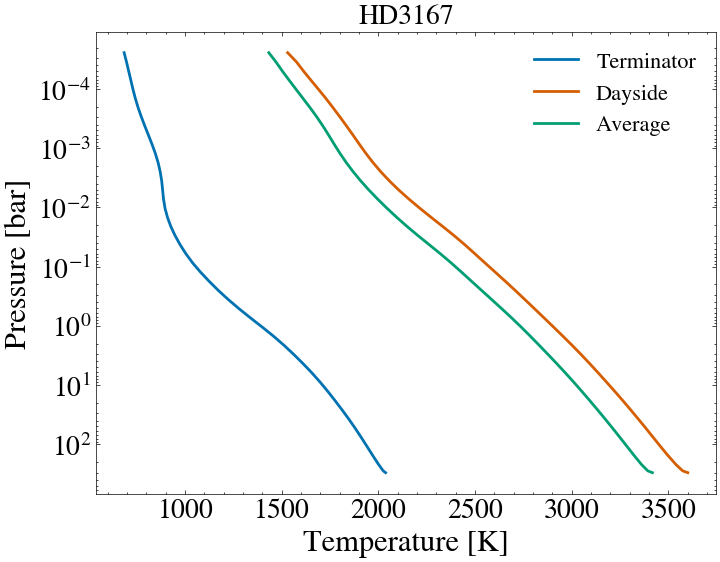

In [13]:
name = 'HD3167'
TP_file = f'PLANETS/{name}/H20_IW4_00001_TP.csv'
data = pd.read_csv(TP_file)

fig = figure(figsize=(8, 6))
frame = fig.add_subplot(1, 1, 1)
pressure = data['Pressure (Pa)']/1e5 #convert to bar

terminator_temp = data['Terminator Temperature (K)']
frame.plot(terminator_temp, pressure, color='#0072B2', linestyle='solid', linewidth=2, label='Terminator')

dayside_temp = data['Substellar Temperature (K)']
frame.plot(dayside_temp, pressure, color='#D55E00', linestyle='solid', linewidth=2, label='Dayside')

average_temp = data['Average Temperature (K)']
frame.plot(average_temp, pressure, color='#009E73', linestyle='solid', linewidth=2, label='Average')

frame.set_xlabel('Temperature [K]')
frame.set_ylabel('Pressure [bar]')

frame.set_title(f'{name}', fontsize=20)
frame.legend(loc='upper right')
frame.invert_yaxis()
frame.set_yscale('log')
frame.grid(False)
savefig(f'thesis-plots/example_TP_profile.pdf', format='pdf')
show()

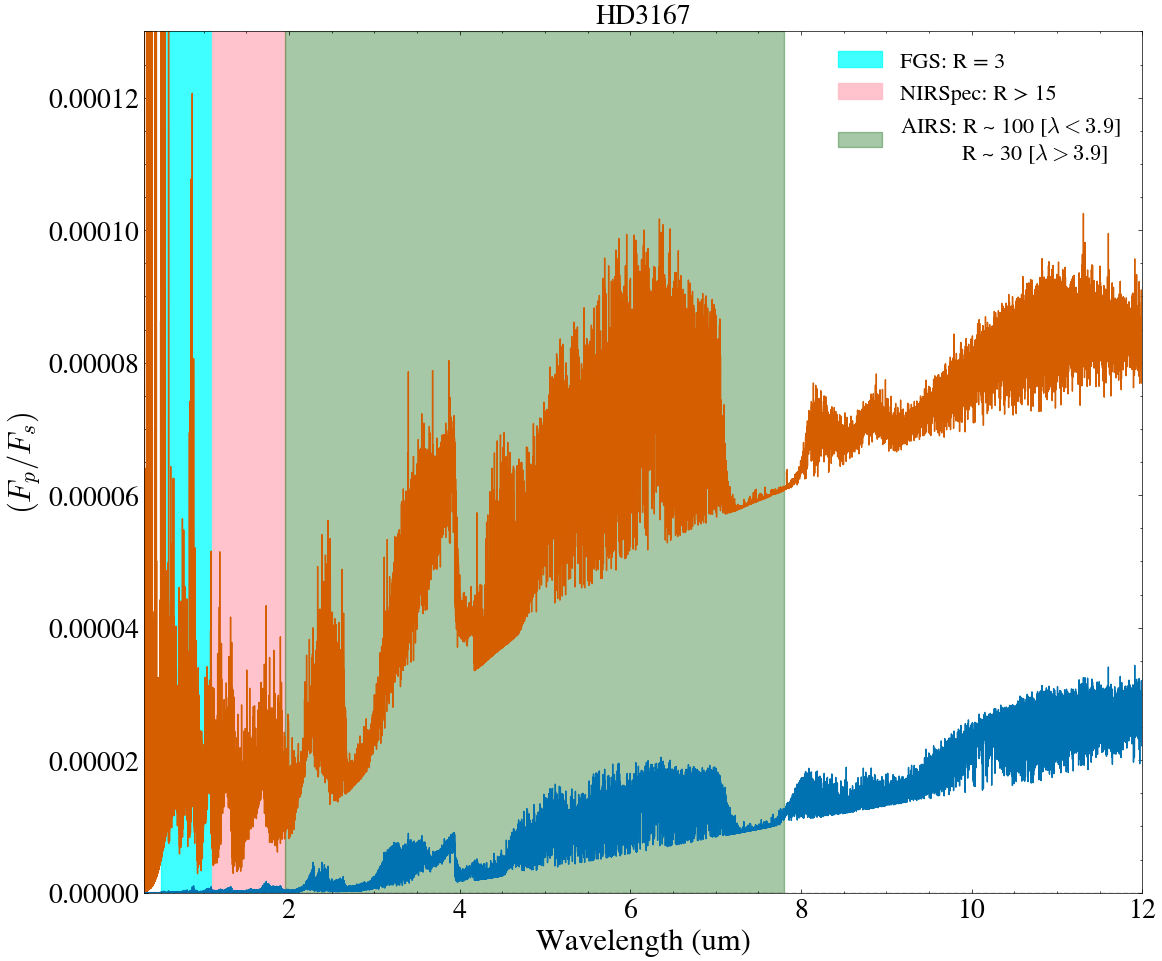

In [125]:
#Dayside and Nightside emission comparison for HD3167

name = 'HD3167'
eclipses = 1
binning = False
sigma = 1

for folder in os.listdir(f"PLANETS/{name}/"):
    simulation_folder = os.path.join(f"PLANETS/{name}/", folder)
    #check if it is a directory
    if not os.path.isdir(simulation_folder):
        continue

    #set-up directories and paths
    outputdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}"
    planetdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}_TP.csv"

    # open TP profile with TauREx
    temp_profile = TemperatureFile(planetdir, skiprows=1, 
                               temp_col=2, press_col=0, 
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                               temp_col=1, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    #read-in the atmospheric composition
    atm_file = None
    for file in os.listdir(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/"):
        if file.endswith("atm.nc"):
            atm_file = os.path.join(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/", file)
            #save filename without extension
            filename = os.path.splitext(atm_file)[0]
            break

    ds = xr.open_dataset(atm_file)

    #extract gas names
    gases = np.array(ds['gases'])
    gases = [m.decode().strip() for m in ds["gases"].values]
    vmr = np.array(ds['x_gas'])

    pressure = np.array(ds['p']) #pressure in Pa
    pmax = pressure.max()
    pmin = pressure.min()

    radius = float(ds['planet_radius']) #planet radius in m
    #convert to Jupiter radii
    radius = radius / astropy.constants.R_jup.value

    #get mixing ratio of each molecule
    H2O_x = float(vmr[:, gases.index('H2O')][0])
    CO2_x = float(vmr[:, gases.index('CO2')][0])
    CH4_x = float(vmr[:, gases.index('CH4')][0])
    CO_x = float(vmr[:, gases.index('CO')][0])
    NH3_x = float(vmr[:, gases.index('NH3')][0])
    N2_x = float(vmr[:, gases.index('N2')][0])
    SO2_x = float(vmr[:, gases.index('SO2')][0])
    S2_x = float(vmr[:, gases.index('S2')][0])
    O2_x = float(vmr[:, gases.index('O2')][0])
    H2_x = float(vmr[:, gases.index('H2')][0])
    H2S_x = float(vmr[:, gases.index('H2S')][0])

    #save in dictionary the planet name, simulation folder, temperature profiles and mixing ratios
    sim_name = os.path.basename(simulation_folder)

    #define chemistry
    chemistry = TaurexChemistry(fill_gases=["N2"])

    chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

    mass = planet_masses[planet_names.index(name)] #Earth masses
    #convert to jupiter masses
    mass = mass / 317.8
    #semi-major axis
    a = planet_distances[planet_names.index(name)] #AU
    #set-up planet in Jupiter masses and radii
    planet = Planet(planet_mass=mass, planet_radius= radius, planet_distance=a)

    star = PhoenixStar(temperature=star_temperature[int(planet_names.index(name))], radius=star_radius[int(planet_names.index(name))], metallicity=star_metallicity[int(planet_names.index(name))], phoenix_path='Phoenix/')

    em = EmissionModel(
    planet=planet,
    temperature_profile=temp_profile,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em_terminator = EmissionModel( 
    planet=planet,
    temperature_profile=temp_profile_terminator,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em.add_contribution(AbsorptionContribution())
    em.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em.add_contribution(RayleighContribution())

    em_terminator.add_contribution(AbsorptionContribution())
    em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em_terminator.add_contribution(RayleighContribution())

    em.build()
    em_terminator.build()

    #wavenumber grid, flux ratio, and transit depth
    wngrid, fpfs, tau, _ = em.model()
    wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

    wlgrid = 10000/wngrid[::-1]; wlgrid_t = 10000/wngrid_t[::-1]
    fpfs = fpfs[::-1]; fpfs_t = fpfs_t[::-1]

    #read-in Ariel noise model
    #check if file exists
    
    if os.path.exists(f"ARIEL/arielrad_{name}/tier2.csv"):
        file = f"ARIEL/arielrad_{name}/tier2.csv"

    ariel = pd.read_csv(file,skiprows=6)
    wl = np.array(ariel['Wavelength [um]'])
    wb = np.array(ariel['Bandwidth [um]'])
    noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional

    #instantiate flux binner with Ariel's wavelength binning
    fb = FluxBinner(wl, wb)
    output = fb.bindown(wlgrid, fpfs)
    output_t = fb.bindown(wlgrid_t, fpfs_t)

    N = eclipses #number of observed eclipses

    plt.figure(figsize=(12,10))
    #plot of spectrum from TauREx
    plt.plot(wlgrid, fpfs, color='#D55E00')
    plt.plot(wlgrid_t, fpfs_t, color='#0072B2')

    yerr = noise / np.sqrt(N) * sigma # sigma confidence interval

    # set appropriate y-limits based on the singular plot
    y_all = np.concatenate([
        output[1] + yerr,
        output[1] - yerr,
        output_t[1] + yerr,
        output_t[1] - yerr,
    ])

    ymin = y_all.min()
    ymax = y_all.max()

    pad = 0.0001 * (ymax - ymin)
    #if ymin - pad < 0:
    #    plt.ylim(0, ymax + pad)
    # else:
    plt.ylim(ymin - pad, ymax + pad)

    # target integration time
    time = planet_transit[planet_names.index(name)] * (N + 1.5) #in hours

    #total telescope time
    t_time = N * planet_period[planet_names.index(name)] #in hours


    #plt.errorbar(output[0], output[1], yerr=noise/np.sqrt(N)*sigma, capsize=5, fmt='o', color='black', alpha=0.67)
    #plt.errorbar(output_t[0], output_t[1], yerr=noise/np.sqrt(N)*sigma, capsize=5, fmt='o', color='black', alpha=0.67)

    plt.axvspan(0.5,1.1, color='cyan', alpha=0.75, zorder=0, label = 'FGS: R = 3')
    plt.axvspan(1.1,1.95, color = 'pink', alpha=0.95, zorder=0, label = 'NIRSpec: R > 15')
    plt.axvspan(1.95,7.8, color = 'darkgreen', alpha=0.35, zorder=0, label = 'AIRS: R ~ 100 [$\lambda<3.9$] \n           R ~ 30 [$\lambda>3.9$]')
    
    #plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))


    plt.xlabel("Wavelength (um)")
    plt.ylabel("$(F_p/F_s)$")
    #plt.xscale("log")
    plt.xlim(0.3, 12)
    plt.ylim(0,0.00013)
    plt.title(f"{name}",fontsize=20) #- {N} eclipses - Integration time: {time:.2f} hours")
    plt.tight_layout()
    plt.hlines(y=0, xmin = -1, xmax = 12, color='black', linestyle='--', alpha=0.5)
    #plt.yscale("log")
    plt.legend(loc='upper right')
    plt.grid(False)

    savefig(f'thesis-plots/{name}_emission_comparison.pdf', format='pdf')

    show()
    close()
    break

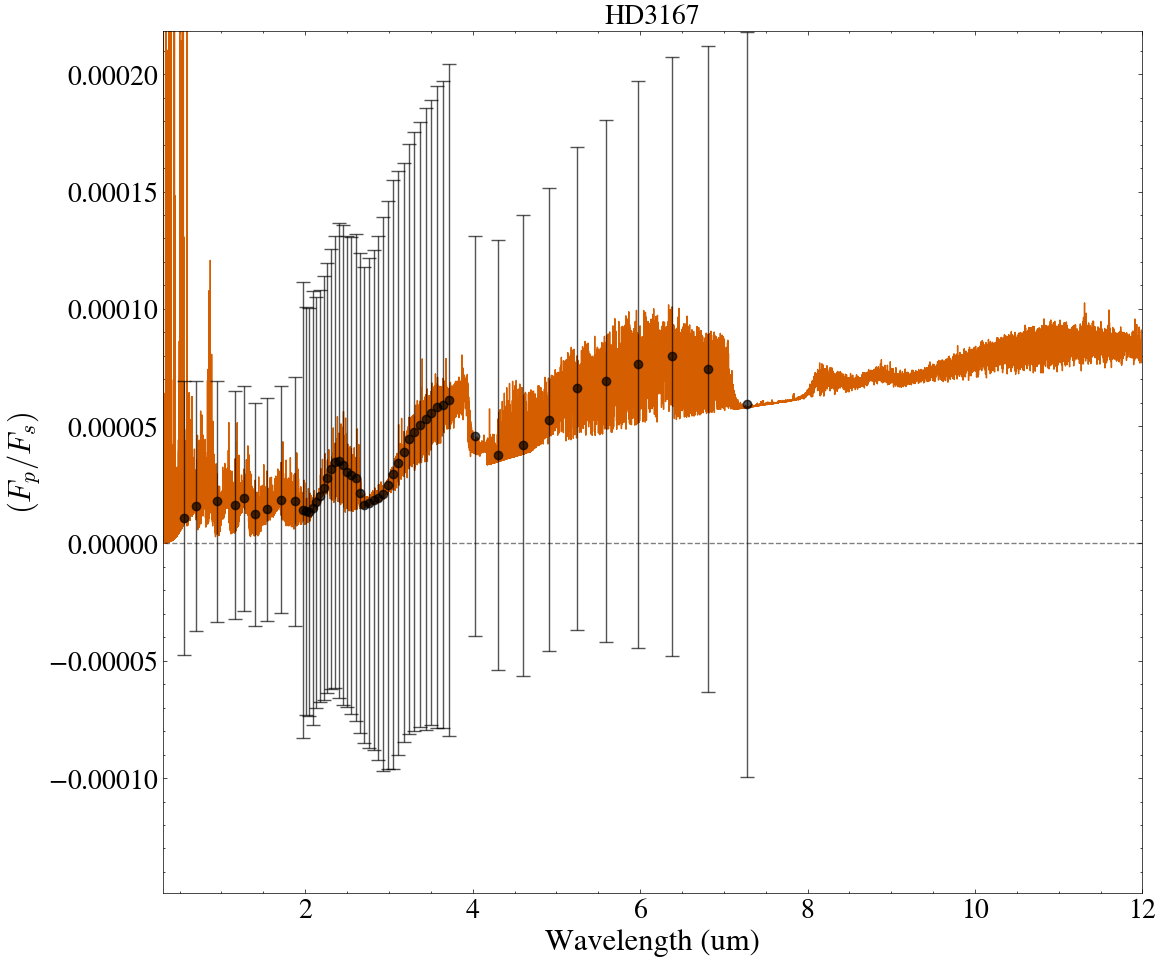

In [124]:
# Dayside and Nightside emission comparison for HD3167

name = 'HD3167'
eclipses = 1
binning = False
sigma = 1

for folder in os.listdir(f"PLANETS/{name}/"):
    simulation_folder = os.path.join(f"PLANETS/{name}/", folder)
    #check if it is a directory
    if not os.path.isdir(simulation_folder):
        continue

    #set-up directories and paths
    outputdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}"
    planetdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}_TP.csv"

    # open TP profile with TauREx
    temp_profile = TemperatureFile(planetdir, skiprows=1, 
                               temp_col=2, press_col=0, 
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                               temp_col=1, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    #read-in the atmospheric composition
    atm_file = None
    for file in os.listdir(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/"):
        if file.endswith("atm.nc"):
            atm_file = os.path.join(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/", file)
            #save filename without extension
            filename = os.path.splitext(atm_file)[0]
            break

    ds = xr.open_dataset(atm_file)

    #extract gas names
    gases = np.array(ds['gases'])
    gases = [m.decode().strip() for m in ds["gases"].values]
    vmr = np.array(ds['x_gas'])

    pressure = np.array(ds['p']) #pressure in Pa
    pmax = pressure.max()
    pmin = pressure.min()

    radius = float(ds['planet_radius']) #planet radius in m
    #convert to Jupiter radii
    radius = radius / astropy.constants.R_jup.value

    #get mixing ratio of each molecule
    H2O_x = float(vmr[:, gases.index('H2O')][0])
    CO2_x = float(vmr[:, gases.index('CO2')][0])
    CH4_x = float(vmr[:, gases.index('CH4')][0])
    CO_x = float(vmr[:, gases.index('CO')][0])
    NH3_x = float(vmr[:, gases.index('NH3')][0])
    N2_x = float(vmr[:, gases.index('N2')][0])
    SO2_x = float(vmr[:, gases.index('SO2')][0])
    S2_x = float(vmr[:, gases.index('S2')][0])
    O2_x = float(vmr[:, gases.index('O2')][0])
    H2_x = float(vmr[:, gases.index('H2')][0])
    H2S_x = float(vmr[:, gases.index('H2S')][0])

    #save in dictionary the planet name, simulation folder, temperature profiles and mixing ratios
    sim_name = os.path.basename(simulation_folder)

    #define chemistry
    chemistry = TaurexChemistry(fill_gases=["N2"])

    chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

    mass = planet_masses[planet_names.index(name)] #Earth masses
    #convert to jupiter masses
    mass = mass / 317.8
    #semi-major axis
    a = planet_distances[planet_names.index(name)] #AU
    #set-up planet in Jupiter masses and radii
    planet = Planet(planet_mass=mass, planet_radius= radius, planet_distance=a)

    star = PhoenixStar(temperature=star_temperature[int(planet_names.index(name))], radius=star_radius[int(planet_names.index(name))], metallicity=star_metallicity[int(planet_names.index(name))], phoenix_path='Phoenix/')

    em = EmissionModel(
    planet=planet,
    temperature_profile=temp_profile,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em_terminator = EmissionModel( 
    planet=planet,
    temperature_profile=temp_profile_terminator,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em.add_contribution(AbsorptionContribution())
    em.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em.add_contribution(RayleighContribution())

    em_terminator.add_contribution(AbsorptionContribution())
    em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em_terminator.add_contribution(RayleighContribution())

    em.build()
    em_terminator.build()

    #wavenumber grid, flux ratio, and transit depth
    wngrid, fpfs, tau, _ = em.model()
    wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

    wlgrid = 10000/wngrid[::-1]; wlgrid_t = 10000/wngrid_t[::-1]
    fpfs = fpfs[::-1]; fpfs_t = fpfs_t[::-1]

    #read-in Ariel noise model
    #check if file exists
    
    if os.path.exists(f"ARIEL/arielrad_{name}/tier2.csv"):
        file = f"ARIEL/arielrad_{name}/tier2.csv"

    ariel = pd.read_csv(file,skiprows=6)
    wl = np.array(ariel['Wavelength [um]'])
    wb = np.array(ariel['Bandwidth [um]'])
    noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional

    #instantiate flux binner with Ariel's wavelength binning
    fb = FluxBinner(wl, wb)
    output = fb.bindown(wlgrid, fpfs)
    output_t = fb.bindown(wlgrid_t, fpfs_t)

    N = eclipses #number of observed eclipses

    plt.figure(figsize=(12,10))
    #plot of spectrum from TauREx
    plt.plot(wlgrid, fpfs, color='#D55E00')
    #plt.plot(wlgrid_t, fpfs_t, color='#0072B2')

    yerr = noise / np.sqrt(N) * sigma # sigma confidence interval

    # set appropriate y-limits based on the singular plot
    y_all = np.concatenate([
        output[1] + yerr,
        output[1] - yerr,
        output_t[1] + yerr,
        output_t[1] - yerr,
    ])

    ymin = y_all.min()
    ymax = y_all.max()

    pad = 0.0001 * (ymax - ymin)
    #if ymin - pad < 0:
    #    plt.ylim(0, ymax + pad)
    # else:
    plt.ylim(ymin - pad, ymax + pad)

    # target integration time
    time = planet_transit[planet_names.index(name)] * (N + 1.5) #in hours

    #total telescope time
    t_time = N * planet_period[planet_names.index(name)] #in hours


    plt.errorbar(output[0], output[1], yerr=noise/np.sqrt(N)*sigma, capsize=5, fmt='o', color='black', alpha=0.67)
    #plt.errorbar(output_t[0], output_t[1], yerr=noise/np.sqrt(N)*sigma, capsize=5, fmt='o', color='black', alpha=0.67)

    #plt.axvspan(0.5,1.1, color='cyan', alpha=0.75, zorder=0, label = 'FGS: R = 3')
    #plt.axvspan(1.1,1.95, color = 'pink', alpha=0.95, zorder=0, label = 'NIRSpec: R > 15')
    #plt.axvspan(1.95,7.8, color = 'darkgreen', alpha=0.35, zorder=0, label = 'AIRS: R ~ 100 [$\lambda<3.9$] \n           R ~ 30 [$\lambda>3.9$]')
    
    #plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))


    plt.xlabel("Wavelength (um)")
    plt.ylabel("$(F_p/F_s)$")
    #plt.xscale("log")
    plt.xlim(0.3, 12)
    #plt.ylim(0,0.00013)
    plt.title(f"{name}",fontsize=20) #- {N} eclipses - Integration time: {time:.2f} hours")
    plt.tight_layout()
    plt.hlines(y=0, xmin = -1, xmax = 12, color='black', linestyle='--', alpha=0.5)
    #plt.yscale("log")
    plt.legend(loc='upper right')
    plt.grid(False)

    savefig(f'thesis-plots/{name}_emission_comparison_with_noise.pdf', format='pdf')

    show()
    close()
    break